# Stage 3A - Direct LLM Benchmark  
## Non-thinking model (`Qwen/Qwen2.5-7B-Instruct`) | 2-class benchmark

This notebook runs the model directly on the held-out test set and evaluates it under **binary sentiment-oriented rating classification derived from Yelp stars (0 = Negative for 1-2 stars, 1 = Positive for 4-5 stars, 3-star reviews removed)**.

This notebook ran on colab with GPU A100.

Saved outputs:
- per-sample predictions CSV
- summary JSON
- one-row metrics CSV
- confusion matrix PNG

Additional metrics included in this version:
- `Off_By_1_Acc`
- `Adj_Error_Ratio`
- `Mid_Confusion_Ratio`
- `MSE`
- `MAE`
- `Eval_Time(s)`
- `Eval_Speed(s/s)`

For the 2-class setting, `Off_By_1_Acc`, `Adj_Error_Ratio`, and `Mid_Confusion_Ratio` are saved as `NaN` because these distance-based or middle-class metrics are not meaningful after collapsing labels into two classes.


In [ ]:
!pip install -q vllm pandas scikit-learn matplotlib seaborn tqdm

from google.colab import drive
drive.mount('/content/drive')

!nvidia-smi


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.9/432.9 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.6/192.6 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 106.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114

In [ ]:
import os
import re
import json
import time
import math
import numpy as np
import pandas as pd
from tqdm import tqdm

from vllm import LLM, SamplingParams
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    mean_absolute_error,
)
import matplotlib.pyplot as plt
import seaborn as sns


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [ ]:
# ============================================
# Paths and basic configuration
# ============================================
DATA_PATH = "/content/drive/MyDrive/Yelp_Project/data/processed/test_data.csv"
OUTPUT_DIR = "/content/drive/MyDrive/Yelp_Project/LLM/qwen2_5_7b_instruct_2class_fulltest"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TEXT_COL = "text"
LABEL_COL = "stars"

TASK_TYPE = "2_class"
RUN_ID = "qwen2_5_7b_instruct_2class_fulltest"
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

BATCH_SIZE = 64
MAX_MODEL_LEN = 4096


In [ ]:
# ============================================
# Load and prepare the test set
# ============================================
df_raw = pd.read_csv(DATA_PATH)
df_raw = df_raw[[TEXT_COL, LABEL_COL]].copy()
df_raw[LABEL_COL] = df_raw[LABEL_COL].astype(int)

if TASK_TYPE == "2_class":
    # 0 = Negative (1-2 stars), 1 = Positive (4-5 stars), drop 3-star reviews
    df_test = df_raw[df_raw[LABEL_COL] != 3].copy()
    df_test["original_stars"] = df_test[LABEL_COL]
    df_test["label"] = df_test[LABEL_COL].apply(lambda x: 0 if x <= 2 else 1)
    EVAL_LABEL_COL = "label"
    LABELS = [0, 1]
    DISPLAY_LABELS = ["Negative (0)", "Positive (1)"]
else:
    df_test = df_raw.copy()
    df_test["original_stars"] = df_test[LABEL_COL]
    df_test["label"] = df_test[LABEL_COL]
    EVAL_LABEL_COL = "label"
    LABELS = [1, 2, 3, 4, 5]
    DISPLAY_LABELS = ["1", "2", "3", "4", "5"]

print(f"Loaded {len(df_test)} samples for {TASK_TYPE}")
print(df_test[[TEXT_COL, "original_stars", "label"]].head())


Loaded 4134 samples for 2_class
                                                text  original_stars  label
0  Tremendous service (Big shout out to Douglas) ...               5      1
1  Best thai food in the area.  Everything was au...               5      1
2  I recently had dinner here with my wife over t...               5      1
3  Stopped by after a Sunday morning walk in the ...               5      1
4  NEVER AGAIN. This is a so called restaurant th...               2      0


In [ ]:
# ============================================
# Prompt builder and parser
# ============================================
def build_prompt(text: str) -> str:
    return (
        "<|im_start|>system\n"
        "You are a Yelp review classifier.\n"
        "Binary task: output 0 for Negative reviews (original rating 1-2 stars) and 1 for Positive reviews (original rating 4-5 stars).\n"
        "Output ONLY one integer: 0 or 1.\n"
        "Do not explain.\n"
        "<|im_end|>\n"
        "<|im_start|>user\n"
        f"Review: {text}\n"
        "<|im_end|>\n"
        "<|im_start|>assistant\n"
    )

def parse_output(text: str):
    text = str(text).strip()
    if text in {"0", "1"}:
        return int(text), True

    lowered = text.lower()
    if re.search(r"\b0\b", text):
        return 0, False
    if re.search(r"\b1\b", text):
        return 1, False
    if "negative" in lowered:
        return 0, False
    if "positive" in lowered:
        return 1, False

    return None, False


In [ ]:
# ============================================
# Model setup and batched inference
# ============================================
sampling_params = SamplingParams(
    temperature=0.0,
    max_tokens=8
)

llm = LLM(
    model=MODEL_NAME,
    trust_remote_code=True,
    max_model_len=MAX_MODEL_LEN
)

all_rows = []

start_time = time.time()

for start in tqdm(range(0, len(df_test), BATCH_SIZE), desc="Inference"):
    end = min(start + BATCH_SIZE, len(df_test))
    batch_df = df_test.iloc[start:end].copy()

    prompts = [build_prompt(text) for text in batch_df[TEXT_COL].tolist()]
    outputs = llm.generate(prompts, sampling_params)

    for i, output in enumerate(outputs):
        raw_text = output.outputs[0].text
        pred, strict_ok = parse_output(raw_text)

        all_rows.append({
            "text": batch_df.iloc[i][TEXT_COL],
            "original_stars": int(batch_df.iloc[i]["original_stars"]),
            "true_label": int(batch_df.iloc[i][EVAL_LABEL_COL]),
            "raw_output": raw_text,
            "pred": pred,
            "strict_format_ok": strict_ok
        })

eval_time_seconds = time.time() - start_time

result_df = pd.DataFrame(all_rows)
pred_path = os.path.join(OUTPUT_DIR, f"{RUN_ID}_predictions.csv")
result_df.to_csv(pred_path, index=False, encoding="utf-8")

print(f"Saved predictions to: {pred_path}")
print(f"Eval time (s): {eval_time_seconds:.2f}")
print(result_df.head())


INFO 03-13 03:05:26 [utils.py:238] non-default args: {'trust_remote_code': True, 'max_model_len': 4096, 'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-7B-Instruct'}


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


INFO 03-13 03:05:52 [model.py:531] Resolved architecture: Qwen2ForCausalLM
INFO 03-13 03:05:52 [model.py:1554] Using max model len 4096
INFO 03-13 03:05:52 [scheduler.py:231] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 03-13 03:05:52 [vllm.py:747] Asynchronous scheduling is enabled.


...

Inference:  98%|█████████▊| 64/65 [00:37<00:00,  1.36it/s]

Rendering prompts:   0%|          | 0/38 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/38 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Inference: 100%|██████████| 65/65 [00:38<00:00,  1.70it/s]

Saved predictions to: /content/drive/MyDrive/Yelp_Project/LLM/qwen2_5_7b_instruct_2class_fulltest/qwen2_5_7b_instruct_2class_fulltest_predictions.csv
Eval time (s): 38.21
                                                text  original_stars  \
0  Tremendous service (Big shout out to Douglas) ...               5   
1  Best thai food in the area.  Everything was au...               5   
2  I recently had dinner here with my wife over t...               5   
3  Stopped by after a Sunday morning walk in the ...               5   
4  NEVER AGAIN. This is a so called restaurant th...               2   

   true_label raw_output  pred  strict_format_ok  
0           1          1     1              True  
1           1          1     1              True  
2           1          1     1              True  
3           1          1     1              True  
4           0          0     0              True  


In [ ]:
# ============================================
# Evaluation
# ============================================
eval_df = result_df.dropna(subset=["pred"]).copy()
eval_df["pred"] = eval_df["pred"].astype(int)

y_true = eval_df["true_label"].to_numpy()
y_pred = eval_df["pred"].to_numpy()

accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
cm = confusion_matrix(y_true, y_pred, labels=LABELS)
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

valid_prediction_rate = result_df["pred"].notna().mean()
strict_format_rate = result_df["strict_format_ok"].mean()
eval_speed = len(result_df) / eval_time_seconds if eval_time_seconds > 0 else np.nan

if TASK_TYPE == "5_class":
    off_by_1_acc = np.mean(np.abs(y_pred - y_true) <= 1)

    incorrect_mask = (y_pred != y_true)
    if incorrect_mask.sum() > 0:
        adj_error_ratio = np.mean(np.abs(y_pred[incorrect_mask] - y_true[incorrect_mask]) == 1)
    else:
        adj_error_ratio = 0.0

    mid_confusion_ratio = np.mean(
        np.isin(y_true, [2, 3, 4]) &
        np.isin(y_pred, [2, 3, 4]) &
        (y_true != y_pred)
    )
else:
    off_by_1_acc = np.nan
    adj_error_ratio = np.nan
    mid_confusion_ratio = np.nan

report = classification_report(
    y_true,
    y_pred,
    labels=LABELS,
    output_dict=True,
    digits=4
)

summary = {
    "Run_ID": RUN_ID,
    "Task_Type": TASK_TYPE,
    "Mode": "Prompt_Inference",
    "Model": MODEL_NAME,
    "Batch_Size": BATCH_SIZE,
    "Accuracy": float(accuracy),
    "Macro_F1": float(macro_f1),
    "Valid_Prediction_Rate": float(valid_prediction_rate),
    "Strict_Format_Rate": float(strict_format_rate),
    "Off_By_1_Acc": None if np.isnan(off_by_1_acc) else float(off_by_1_acc),
    "Adj_Error_Ratio": None if np.isnan(adj_error_ratio) else float(adj_error_ratio),
    "Mid_Confusion_Ratio": None if np.isnan(mid_confusion_ratio) else float(mid_confusion_ratio),
    "MSE": float(mse),
    "MAE": float(mae),
    "Eval_Time(s)": float(eval_time_seconds),
    "Eval_Speed(s/s)": float(eval_speed),
    "Confusion_Matrix": cm.tolist(),
    "Classification_Report": report
}

summary_path = os.path.join(OUTPUT_DIR, f"{RUN_ID}_summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

metrics_row = pd.DataFrame([{
    "Run_ID": RUN_ID,
    "Task_Type": TASK_TYPE,
    "Mode": "Prompt_Inference",
    "Model": MODEL_NAME,
    "Batch_Size": BATCH_SIZE,
    "Accuracy": accuracy,
    "Macro_F1": macro_f1,
    "Valid_Prediction_Rate": valid_prediction_rate,
    "Strict_Format_Rate": strict_format_rate,
    "Off_By_1_Acc": off_by_1_acc,
    "Adj_Error_Ratio": adj_error_ratio,
    "Mid_Confusion_Ratio": mid_confusion_ratio,
    "MSE": mse,
    "MAE": mae,
    "Eval_Time(s)": eval_time_seconds,
    "Eval_Speed(s/s)": eval_speed
}])

metrics_csv_path = os.path.join(OUTPUT_DIR, f"{RUN_ID}_metrics.csv")
metrics_row.to_csv(metrics_csv_path, index=False, encoding="utf-8")

print("Saved summary JSON to:", summary_path)
print("Saved metrics CSV to :", metrics_csv_path)
metrics_row


Saved summary JSON to: /content/drive/MyDrive/Yelp_Project/LLM/qwen2_5_7b_instruct_2class_fulltest/qwen2_5_7b_instruct_2class_fulltest_summary.json
Saved metrics CSV to : /content/drive/MyDrive/Yelp_Project/LLM/qwen2_5_7b_instruct_2class_fulltest/qwen2_5_7b_instruct_2class_fulltest_metrics.csv


,Run_ID,Task_Type,Mode,Model,Batch_Size,Accuracy,Macro_F1,Valid_Prediction_Rate,Strict_Format_Rate,Off_By_1_Acc,Adj_Error_Ratio,Mid_Confusion_Ratio,MSE,MAE,Eval_Time(s),Eval_Speed(s/s)
0,qwen2_5_7b_instruct_2class_fulltest,2_class,Prompt_Inference,Qwen/Qwen2.5-7B-Instruct,64,0.981616,0.981616,1.0,1.0,NaN,NaN,NaN,0.018384,0.018384,38.210995,108.188756


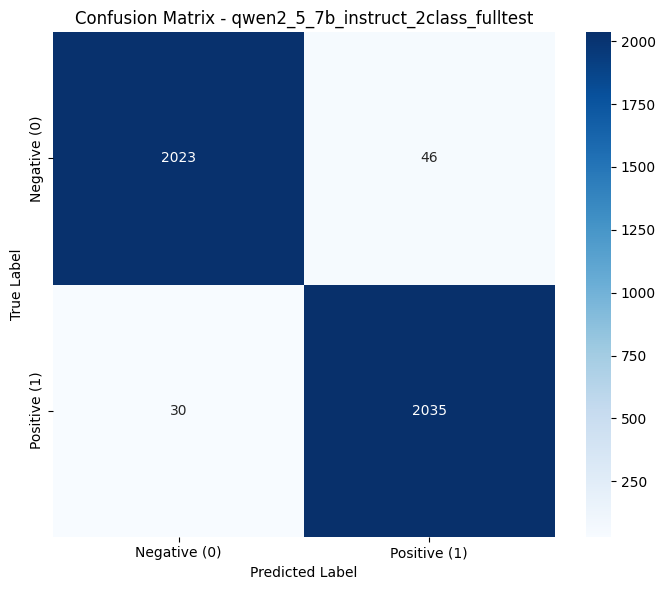

Saved confusion matrix to: /content/drive/MyDrive/Yelp_Project/LLM/qwen2_5_7b_instruct_2class_fulltest/qwen2_5_7b_instruct_2class_fulltest_confusion_matrix.png


In [ ]:
# ============================================
# Confusion matrix
# ============================================
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=DISPLAY_LABELS,
    yticklabels=DISPLAY_LABELS
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix - {RUN_ID}")
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, f"{RUN_ID}_confusion_matrix.png")
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved confusion matrix to:", fig_path)


In [ ]:
# ============================================
# Final console summary
# ============================================
print(f"Run_ID              : {RUN_ID}")
print(f"Task_Type           : {TASK_TYPE}")
print(f"Mode                : Prompt_Inference")
print(f"Model               : {MODEL_NAME}")
print(f"Batch_Size          : {BATCH_SIZE}")
print(f"Accuracy            : {accuracy:.4f}")
print(f"Macro_F1            : {macro_f1:.4f}")
print(f"Valid_Prediction_Rate: {valid_prediction_rate:.4f}")
print(f"Strict_Format_Rate  : {strict_format_rate:.4f}")
print(f"Off_By_1_Acc        : {off_by_1_acc}")
print(f"Adj_Error_Ratio     : {adj_error_ratio}")
print(f"Mid_Confusion_Ratio : {mid_confusion_ratio}")
print(f"MSE                 : {mse:.6f}")
print(f"MAE                 : {mae:.6f}")
print(f"Eval_Time(s)        : {eval_time_seconds:.2f}")
print(f"Eval_Speed(s/s)     : {eval_speed:.4f}")


Run_ID              : qwen2_5_7b_instruct_2class_fulltest
Task_Type           : 2_class
Mode                : Prompt_Inference
Model               : Qwen/Qwen2.5-7B-Instruct
Batch_Size          : 64
Accuracy            : 0.9816
Macro_F1            : 0.9816
Valid_Prediction_Rate: 1.0000
Strict_Format_Rate  : 1.0000
Off_By_1_Acc        : nan
Adj_Error_Ratio     : nan
Mid_Confusion_Ratio : nan
MSE                 : 0.018384
MAE                 : 0.018384
Eval_Time(s)        : 38.21
Eval_Speed(s/s)     : 108.1888
